In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [37]:
file_path = r"C:\Users\Aagam\Code Playground\ML Project\data\heart-disease-dataset.xls"
df = pd.read_csv(file_path) 

In [38]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [39]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [40]:
df.groupby('target').mean()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,56.601449,0.826087,0.478261,134.398551,251.086957,0.159420,0.449275,139.101449,0.550725,1.585507,1.166667,1.166667,2.543478
1,52.496970,0.563636,1.375758,129.303030,242.230303,0.139394,0.593939,158.466667,0.139394,0.583030,1.593939,0.363636,2.121212


In [41]:
X = df.iloc[:,0:13]
Y = df['target']

In [42]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [43]:
X.shape

(303, 13)

In [44]:
X.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000


In [45]:
Y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

### Target Distribution

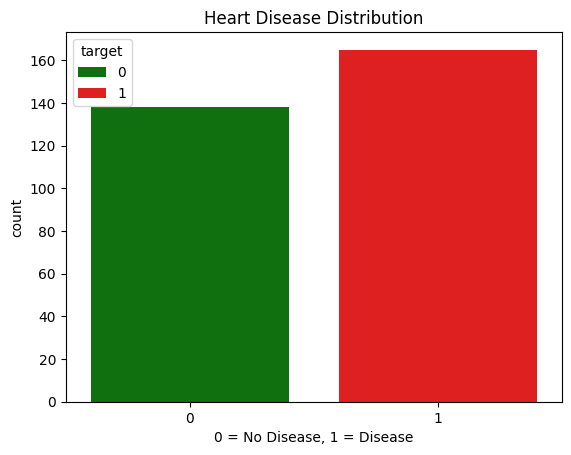

In [46]:
sns.countplot(x=Y, hue=Y, palette=['green', 'red'])
plt.title("Heart Disease Distribution")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.show()

### Age vs Heart Disease

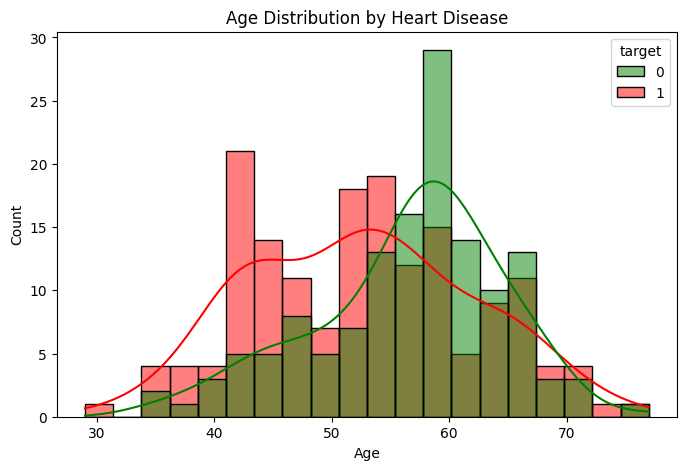

In [47]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue=Y, bins=20, kde=True, palette=['green','red'])
plt.title("Age Distribution by Heart Disease")
plt.xlabel("Age")
plt.show()

### Gender vs Heart Disease

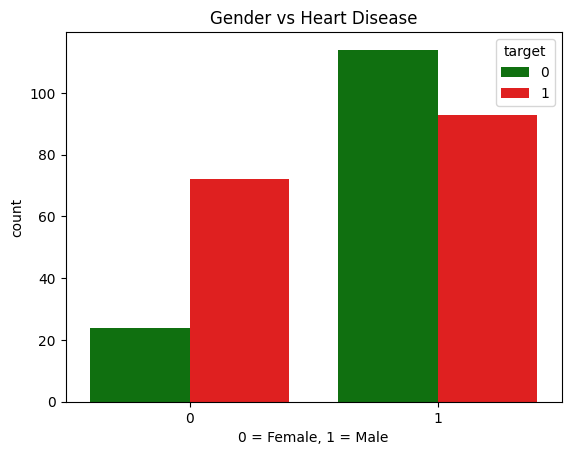

In [48]:
sns.countplot(x='sex', hue=Y, data=df, palette=['green','red'])
plt.title("Gender vs Heart Disease")
plt.xlabel("0 = Female, 1 = Male")
plt.show()

### Correlation Heatmap

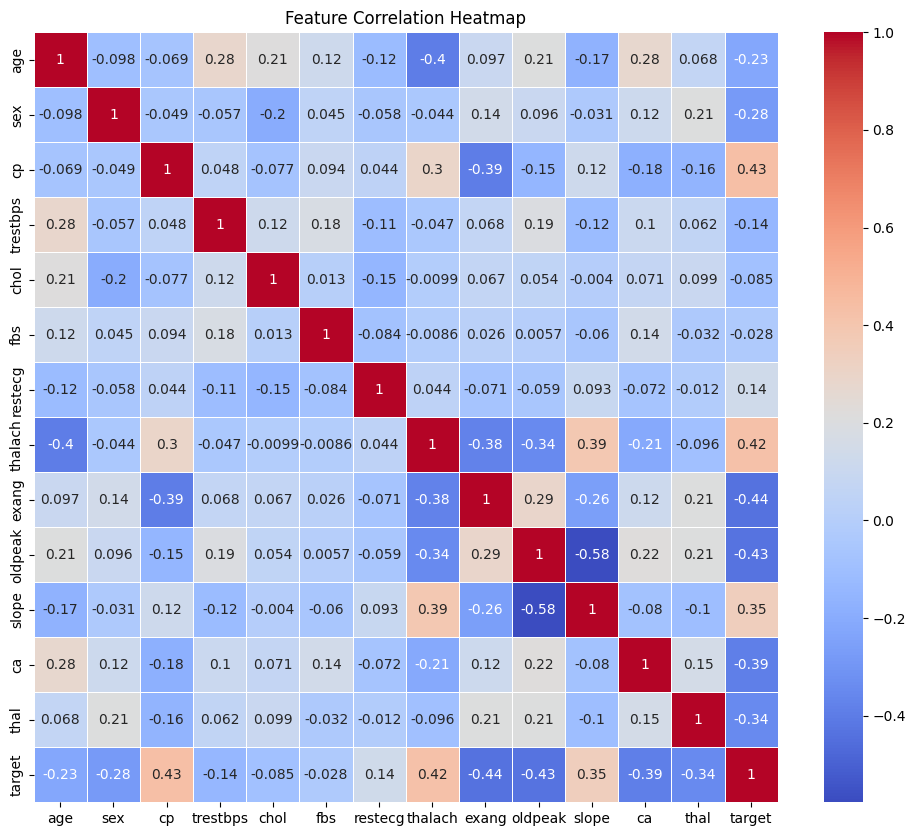

In [49]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

### Chest Pain vs Disease

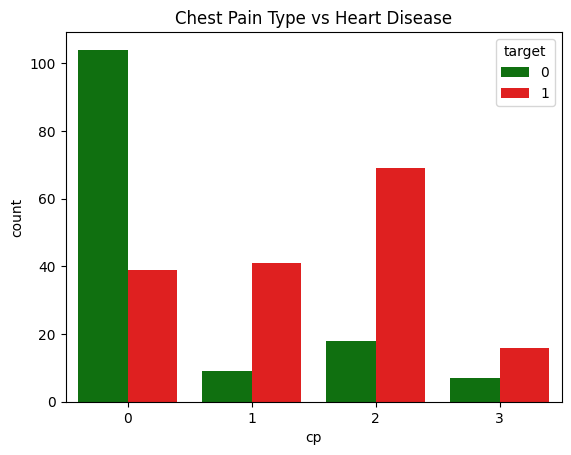

In [50]:
sns.countplot(x='cp', hue=Y, data=df, palette=['green','red'])
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

### Cholesterol vs Disease

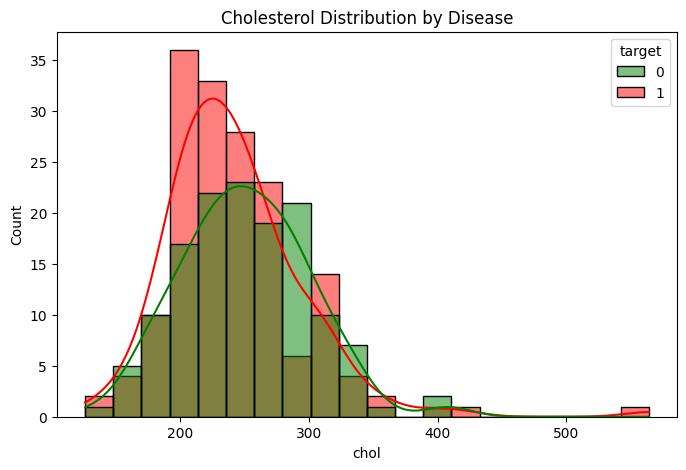

In [51]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='chol', hue=Y, bins=20, kde=True, palette=['green','red'])
plt.title("Cholesterol Distribution by Disease")
plt.show()

### Boxplot

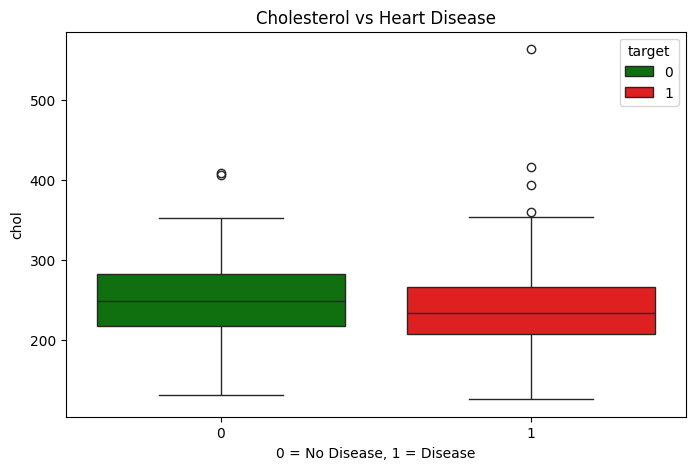

In [52]:
plt.figure(figsize=(8,5))
sns.boxplot(x=Y, y='chol', data=df, hue=Y, palette=['green','red'])
plt.title("Cholesterol vs Heart Disease")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.show()

### Maximum Heart Rate vs Disease

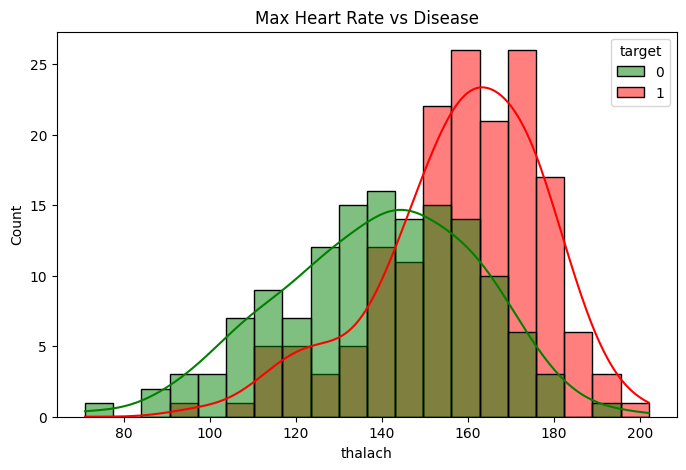

In [53]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='thalach', hue=Y, bins=20, kde=True, palette=['green','red'])
plt.title("Max Heart Rate vs Disease")
plt.show()

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [56]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [57]:
print(X.shape, X_train.shape, X_test.shape)

(303, 13) (242, 13) (61, 13)


In [58]:
# Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train, Y_train)

# Predictions
lr_train_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)

In [59]:
# Create SVM model
svm_model = svm.SVC(kernel='linear')

# Train SVM
svm_model.fit(X_train, Y_train)

# Predictions
svm_train_pred = svm_model.predict(X_train)
svm_test_pred = svm_model.predict(X_test)

In [60]:
# Decision Tree Model
dt_model = DecisionTreeClassifier(random_state=2)

dt_model.fit(X_train, Y_train)

dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

In [61]:
# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=2)

rf_model.fit(X_train, Y_train)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

In [62]:
def evaluate_model(y_train, y_train_pred, y_test, y_test_pred, model_name):
    
    print(f"\n🔹 {model_name} Performance")

    print("\n--- Training Data ---")
    print("Accuracy :", accuracy_score(y_train, y_train_pred))
    print("Precision:", precision_score(y_train, y_train_pred))
    print("Recall   :", recall_score(y_train, y_train_pred))
    print("F1 Score :", f1_score(y_train, y_train_pred))

    print("\n--- Testing Data ---")
    print("Accuracy :", accuracy_score(y_test, y_test_pred))
    print("Precision:", precision_score(y_test, y_test_pred))
    print("Recall   :", recall_score(y_test, y_test_pred))
    print("F1 Score :", f1_score(y_test, y_test_pred))
    
    print("\nConfusion Matrix (Test):\n", confusion_matrix(y_test, y_test_pred))

In [63]:
evaluate_model(Y_train, lr_train_pred, Y_test, lr_test_pred, "Logistic Regression")

evaluate_model(Y_train, svm_train_pred, Y_test, svm_test_pred, "SVM")

evaluate_model(Y_train, dt_train_pred, Y_test, dt_test_pred, "Decision Tree")

evaluate_model(Y_train, rf_train_pred, Y_test, rf_test_pred, "Random Forest")


🔹 Logistic Regression Performance

--- Training Data ---
Accuracy : 0.8471074380165289
Precision: 0.8275862068965517
Recall   : 0.9090909090909091
F1 Score : 0.8664259927797834

--- Testing Data ---
Accuracy : 0.7868852459016393
Precision: 0.8125
Recall   : 0.7878787878787878
F1 Score : 0.8

Confusion Matrix (Test):
 [[22  6]
 [ 7 26]]

🔹 SVM Performance

--- Training Data ---
Accuracy : 0.859504132231405
Precision: 0.8223684210526315
Recall   : 0.946969696969697
F1 Score : 0.8802816901408451

--- Testing Data ---
Accuracy : 0.819672131147541
Precision: 0.8055555555555556
Recall   : 0.8787878787878788
F1 Score : 0.8405797101449275

Confusion Matrix (Test):
 [[21  7]
 [ 4 29]]

🔹 Decision Tree Performance

--- Training Data ---
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

--- Testing Data ---
Accuracy : 0.7704918032786885
Precision: 0.7878787878787878
Recall   : 0.7878787878787878
F1 Score : 0.7878787878787878

Confusion Matrix (Test):
 [[21  7]
 [ 7 26]]

🔹 Random Fore

In [64]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'Random Forest'],
    
    'Train Accuracy': [
        accuracy_score(Y_train, lr_train_pred),
        accuracy_score(Y_train, svm_train_pred),
        accuracy_score(Y_train, dt_train_pred),
        accuracy_score(Y_train, rf_train_pred)
    ],
    
    'Test Accuracy': [
        accuracy_score(Y_test, lr_test_pred),
        accuracy_score(Y_test, svm_test_pred),
        accuracy_score(Y_test, dt_test_pred),
        accuracy_score(Y_test, rf_test_pred)
    ]
})

print("\nTrain vs Test Accuracy:\n")
print(comparison)


Train vs Test Accuracy:

                 Model  Train Accuracy  Test Accuracy
0  Logistic Regression        0.847107       0.786885
1                  SVM        0.859504       0.819672
2        Decision Tree        1.000000       0.770492
3        Random Forest        1.000000       0.786885


In [65]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(Y_test, lr_test_pred),
        accuracy_score(Y_test, svm_test_pred),
        accuracy_score(Y_test, dt_test_pred),
        accuracy_score(Y_test, rf_test_pred)
    ],
    'Precision': [
        precision_score(Y_test, lr_test_pred),
        precision_score(Y_test, svm_test_pred),
        precision_score(Y_test, dt_test_pred),
        precision_score(Y_test, rf_test_pred)
    ],
    'Recall': [
        recall_score(Y_test, lr_test_pred),
        recall_score(Y_test, svm_test_pred),
        recall_score(Y_test, dt_test_pred),
        recall_score(Y_test, rf_test_pred)
    ],
    'F1 Score': [
        f1_score(Y_test, lr_test_pred),
        f1_score(Y_test, svm_test_pred),
        f1_score(Y_test, dt_test_pred),
        f1_score(Y_test, rf_test_pred)
    ]
})

print("\nModel Comparison:\n")
print(comparison)


Model Comparison:

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.786885   0.812500  0.787879  0.800000
1                  SVM  0.819672   0.805556  0.878788  0.840580
2        Decision Tree  0.770492   0.787879  0.787879  0.787879
3        Random Forest  0.786885   0.812500  0.787879  0.800000


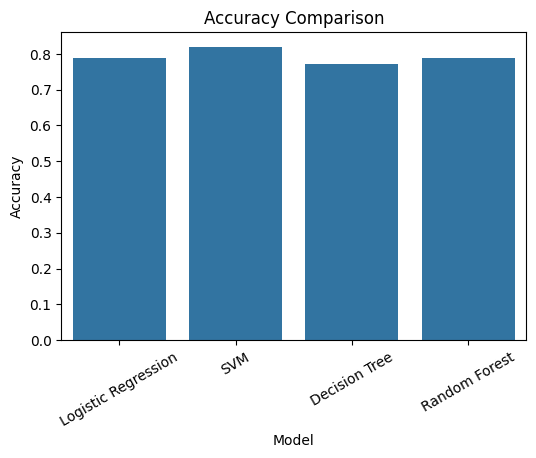

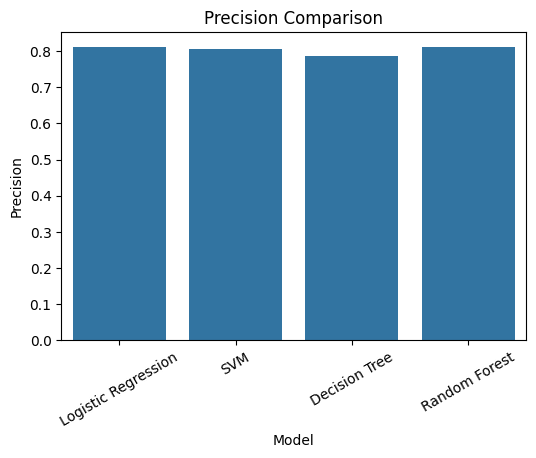

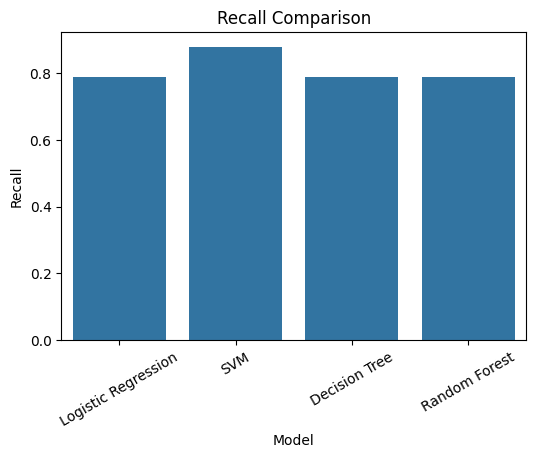

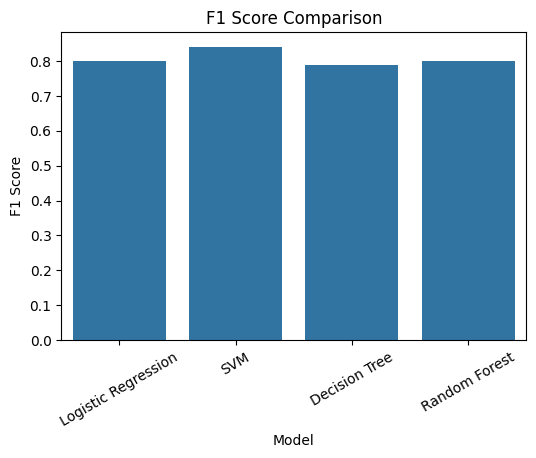

In [66]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for metric in metrics:
    plt.figure(figsize=(6,4))
    sns.barplot(x='Model', y=metric, data=comparison)
    plt.title(f"{metric} Comparison")
    plt.xticks(rotation=30)
    plt.show()

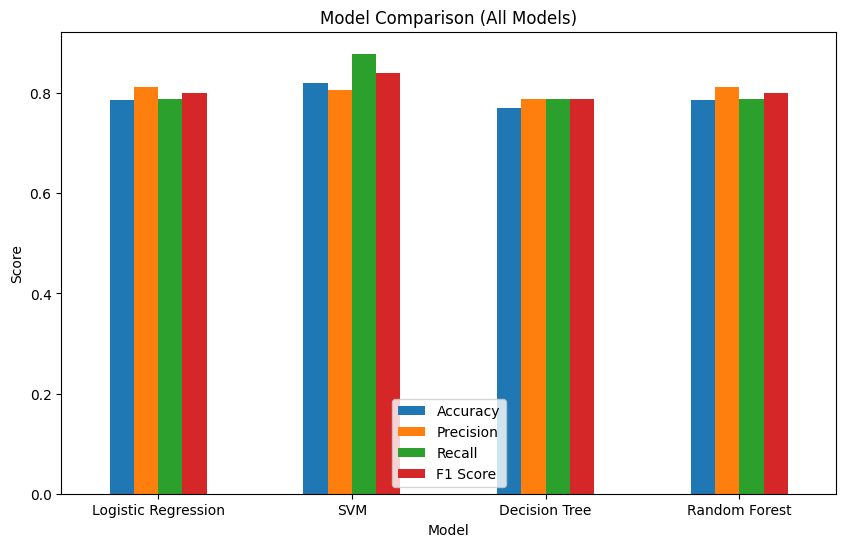

In [67]:
comparison.set_index('Model').plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison (All Models)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [68]:
#input_data = (62,0,0,10,268,0,0,160,0,3.6,0,2,2)
input_data = (99,78,80,199,267,37,44,180,90,3.6,0,2,2)

# change the input data to a numpy array
input_data_as_numpy_array= np.asarray(input_data)

# reshape the numpy array as we are predicting for only on instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# Scale the input data
input_data_scaled = scaler.transform(input_data_reshaped)
print(input_data_scaled)

# SVM Prediction
svm_prediction = svm_model.predict(input_data_scaled)
print(svm_prediction)

print("SVM Prediction:")
if (svm_prediction[0]== 0):
  print('The Person does not have a Heart Disease')
else:
  print('The Person has heart disease')

[[  4.92259436 166.18655622  76.70515338   3.84805257   0.40073269
  103.62904923  82.80510889   1.32735793 191.19341986   2.20884228
   -2.27457861   1.24459328  -0.51292188]]
[0]
SVM Prediction:
The Person does not have a Heart Disease


c:\Users\Aagam\Code Playground\ML Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Saving the Model

In [69]:
import joblib

In [70]:
joblib.dump({
    'model': svm_model,
    'scaler': scaler
}, 'models/heart_disease_model.pkl')


['models/heart_disease_model.pkl']